#### Tissera Ana Paula - `Notebook TP3`

In [3]:
%load_ext autoreload
%autoreload 2

##### Imports

In [4]:
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import os
import itertools
import cupy as cp

In [5]:
import cupy as cp

# Obtener el índice del dispositivo actual
device_id = cp.cuda.Device().id

# Obtener el nombre de la GPU actual
device_name = cp.cuda.runtime.getDeviceProperties(device_id)['name']

print(f"Usando GPU {device_id}: {device_name}")

Usando GPU 0: b'NVIDIA GeForce RTX 3050 Laptop GPU'


In [6]:
SEED = 42

### `1.` **Análisis y Preprocesamiento de Datos**

In [7]:
X_images = cp.load("data/X_images.npy")
y_images = cp.load("data/y_images.npy")


In [8]:
print("Forma de X:", X_images.shape)
print("Forma de y:", y_images.shape)
print("Etiquetas únicas:", cp.unique(y_images))


Forma de X: (5000, 784)
Forma de y: (5000,)
Etiquetas únicas: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48]


### Visualización de imágenes

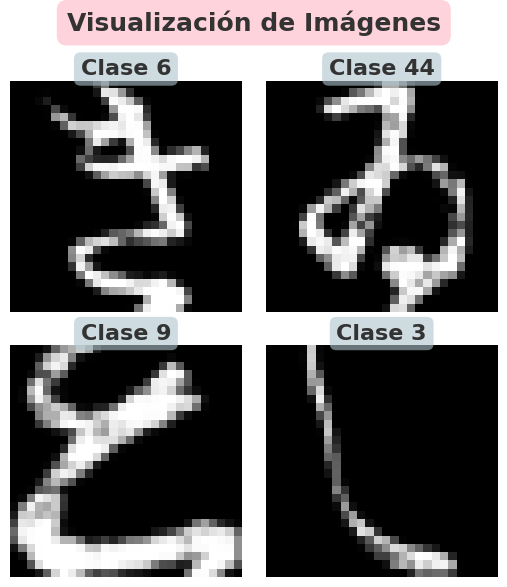

In [9]:
from src.plot import plot_images

# Mapa de nombres
name_map = {int(i): f"Clase {int(i)}" for i in cp.unique(y_images)}

# Selección aleatoria de índices por clase
cp.random.seed(SEED)
clases = cp.unique(y_images)
clases_seleccion = cp.random.choice(clases, size=4, replace=False)
indices = []
for cl in clases_seleccion:
    idxs_cl = cp.where(y_images == cl)[0]
    # pedimos tamaño 1 y extraemos el escalar
    idx = int(cp.random.choice(idxs_cl, size=1)[0])
    indices.append(idx)

# Visualización de imágenes
plot_images(
    X_images, y_images,
    indices=indices,
    n_cols=2,
    suptitle="Visualización de Imágenes",
    name_map=name_map,
    random_seed=SEED
)

In [10]:
print("▶ X:", type(X_images), "shape =", X_images.shape, "dtype =", X_images.dtype)
print("▶ y:", type(y_images), "shape =", y_images.shape, "dtype =", y_images.dtype)

# Si X está aplanado, chequeá min/max
print("▶ X min/max:", X_images.min(), "/", X_images.max())

▶ X: <class 'cupy.ndarray'> shape = (5000, 784) dtype = float32
▶ y: <class 'cupy.ndarray'> shape = (5000,) dtype = int64
▶ X min/max: 0.0 / 255.0


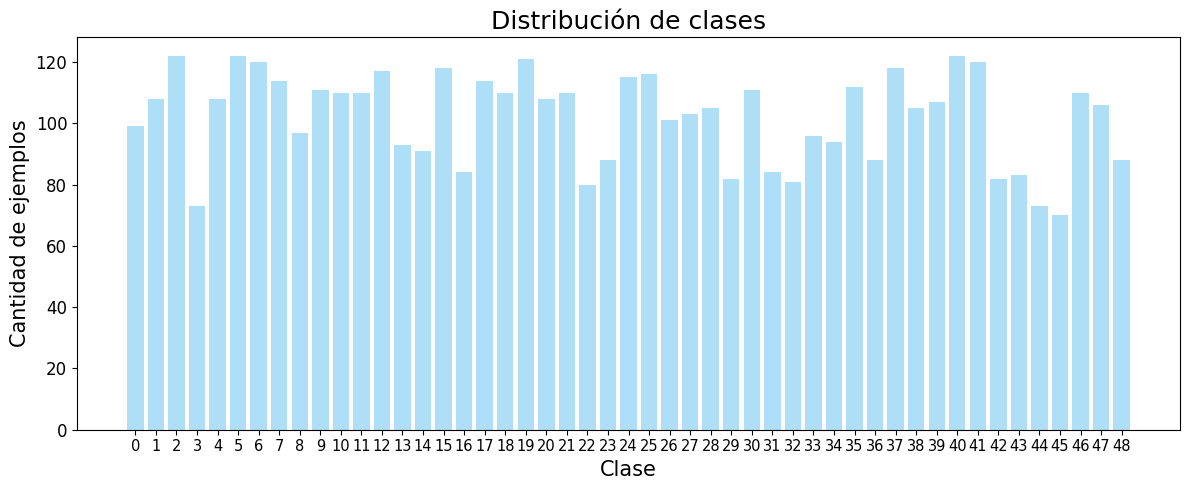

In [11]:
from src.plot import plot_class_distribution
plot_class_distribution(y_images, name_map=name_map, figsize=(12, 5), color='#AEDFF7')

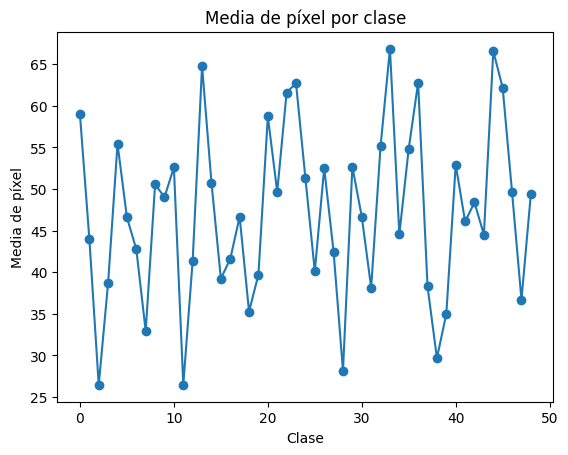

In [12]:
# Media de píxel por clase
medias = [X_images[y_images == cl].mean() for cl in clases]
# Convertir a NumPy para plotting
medias_cp = cp.asnumpy(cp.stack(medias))
clases_cp = cp.asnumpy(clases)
plt.plot(clases_cp, medias_cp, marker='o')
plt.xlabel("Clase")
plt.ylabel("Media de píxel")
plt.title("Media de píxel por clase")
plt.show()

In [13]:
print("Media de píxeles en todo X:", X_images.mean())
print("Desviación estándar de píxeles:", X_images.std())

Media de píxeles en todo X: 46.525505
Desviación estándar de píxeles: 87.5637


#### División del dataset


In [14]:
from src.data_splitting import split_data

X_dev, y_dev, X_test, y_test = split_data(X_images, y_images, ratio=0.2, seed=SEED)
X_train, y_train, X_val, y_val = split_data(X_dev, y_dev, ratio=0.2, seed=SEED)




#### Normalización

In [15]:
# Normalización y conversión de tipo
X_train = X_train.astype(cp.float32) / 255.0
X_val   = X_val.astype(cp.float32)   / 255.0
X_test  = X_test.astype(cp.float32)  / 255.0
X_dev   = X_dev.astype(cp.float32)   / 255.0

# # Guardar procesados
# out_dir = "data/processed"
# os.makedirs(out_dir, exist_ok=True)
# cp.savez_compressed(os.path.join(out_dir, "train.npz"), X=X_train, y=y_train)
# cp.savez_compressed(os.path.join(out_dir, "val.npz"),   X=X_val,   y=y_val)
# cp.savez_compressed(os.path.join(out_dir, "test.npz"),  X=X_test,  y=y_test)


### `2.` **Implementación y Entrenamiento de una Red Neuronal Básica**

red neuronal con 2 capas ocultas, con 100 y 80 nodos

In [16]:
from src.Neural_Network import NeuralNetwork

Epochs: 100%|██████████| 1000/1000 [00:29<00:00, 34.47it/s]


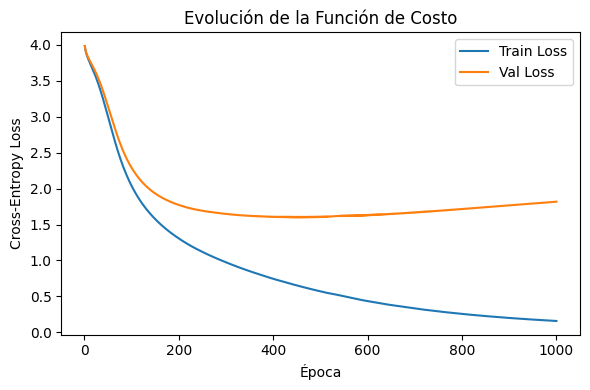

In [17]:
# Configuración y entrenamiento de la red
input_size    = X_train.shape[1]
hidden1, hidden2 = 100, 80
n_classes     = int(cp.max(y_train)) + 1
epochs        = 1000

# One-hot encoding
Y_train_oh = cp.eye(n_classes, dtype=cp.float32)[y_train]
Y_val_oh   = cp.eye(n_classes, dtype=cp.float32)[y_val]

M0 = NeuralNetwork(
    layer_sizes=[input_size, hidden1, hidden2, n_classes],
    learning_rate=0.1,
    seed=SEED
)

train_losses, val_losses = M0.train_bp(
    X_train, Y_train_oh,
    X_val= X_val, Y_val=Y_val_oh,
    epochs=epochs,
    plot=True
)

### Métricas en Conjunto de Entrenamiento
**Accuracy:** **0.9894**  
**Cross-Entropy Loss:** 0.1579  


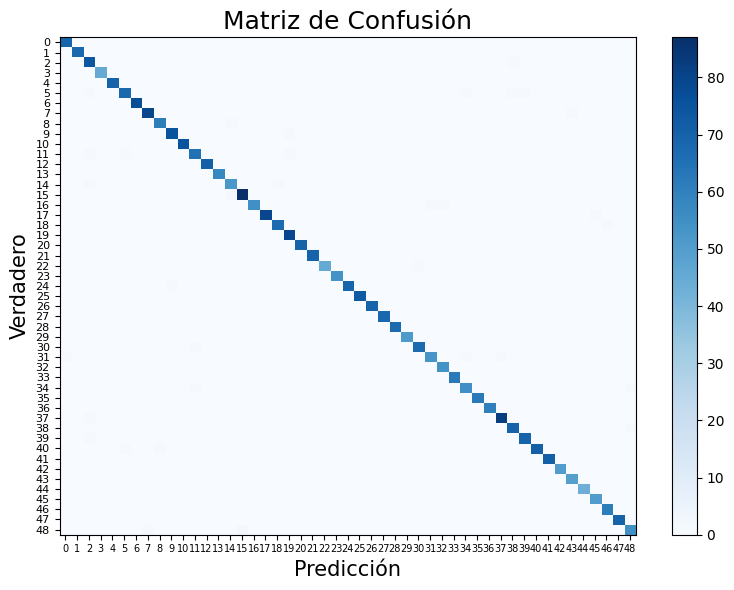

### Métricas en Conjunto de Validación
**Accuracy:** **0.6088**  
**Cross-Entropy Loss:** 1.8189  


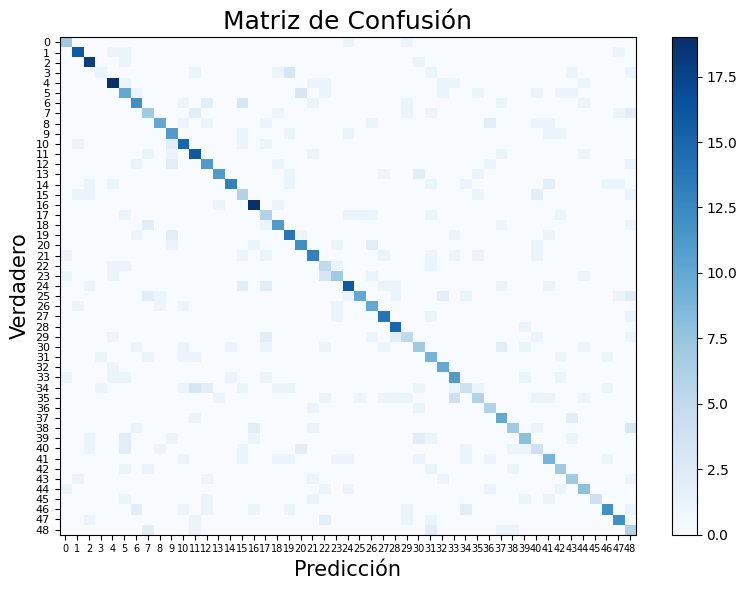

In [18]:

from src.metrics import Metrics  # importa la clase que guardaste en metrics.py

# Predicciones y métricas
Y_hat_train = M0.forward(X_train)
y_proba_train = Y_hat_train.T
y_pred_train  = cp.argmax(Y_hat_train, axis=0)

Y_hat_val   = M0.forward(X_val)
y_proba_val = Y_hat_val.T
y_pred_val  = cp.argmax(Y_hat_val, axis=0)

met_train = Metrics(y_true=y_train, y_pred=y_pred_train, y_proba=y_proba_train)
met_train.report_metrics(title="Métricas en Conjunto de Entrenamiento", show_matrix_table=False)

met_val = Metrics(y_true=y_val, y_pred=y_pred_val, y_proba=y_proba_val)
met_val.report_metrics(title="Métricas en Conjunto de Validación")



### `3.` **Implementación y Entrenamiento de una Red Neuronal Avanzada**

3.1)

In [26]:
epochs = 300

# Comparativa de optimizadores y parámetros
configs = {
    'Batch GD':                 {'optimizer':'gd'},
    'Rate Scheduling Lineal':   {'lr_schedule':'linear', 'learning_rate':0.2},
    'Rate Scheduling Exp':      {'lr_schedule':'exp',    'learning_rate':0.5},
    'Mini-batch Stochastic GD': {'optimizer':'mb',       'batch_size':32,    'learning_rate':0.01},
    'Adam':                     {'optimizer':'adam',     'learning_rate':0.01},
    'L2 (λ=1e-3)':              {'l2_lambda':1e-3},
    'EarlyStop (p=5)':          {'early_stopping':True,  'patience':5},
    'Dropout (p=0.2)':          {'dropout_p':0.2},
    'BatchNorm':                {'use_batchnorm':True,   'learning_rate':0.02},
}

results = []
all_train_losses = {}
all_val_losses   = {}

for name, params in configs.items():
    # --- Instanciar ---
    nn = NeuralNetwork(
        layer_sizes=[input_size, hidden1, hidden2, n_classes],
        learning_rate=params.get('learning_rate', 0.1),
        seed=SEED,
        optimizer=params.get('optimizer', 'gd'),
        batch_size=params.get('batch_size', None),
        l2_lambda=params.get('l2_lambda', 0.0),
        dropout_p=params.get('dropout_p', 0.0),
        use_batchnorm=params.get('use_batchnorm', False),
        early_stopping=params.get('early_stopping', False),
        patience=params.get('patience', 5),
    )

    # --- Scheduler ---
    lr_schedule = None
    if params.get('lr_schedule') == 'linear':
        lr_schedule = nn.get_linear_schedule(final_lr=0.001, max_epochs=epochs)
    elif params.get('lr_schedule') == 'exp':
        lr_schedule = nn.get_exponential_schedule(decay_rate=0.05)

    # --- Entrenamiento y captura de pérdidas ---
    train_losses, val_losses = nn.train_bp(
        X_train, Y_train_oh,
        X_val=X_val, Y_val=Y_val_oh,
        epochs=epochs,
        plot=False,
        lr_schedule=lr_schedule
    )
    all_train_losses[name] = train_losses
    all_val_losses[name]   = val_losses

    # --- Métricas en entrenamiento ---
    Yhat_tr   = nn.forward(X_train, train=False)
    ypred_tr  = cp.argmax(Yhat_tr, axis=0)
    yproba_tr = Yhat_tr.T
    m_tr      = Metrics(y_true=y_train, y_pred=ypred_tr, y_proba=yproba_tr)
    acc_tr    = m_tr.accuracy()
    ce_tr     = m_tr.cross_entropy()

    # --- Métricas en validación ---
    Yhat_v   = nn.forward(X_val, train=False)
    ypred_v  = cp.argmax(Yhat_v, axis=0)
    yproba_v = Yhat_v.T
    m_v      = Metrics(y_true=y_val, y_pred=ypred_v, y_proba=yproba_v)
    acc_v    = m_v.accuracy()
    ce_v     = m_v.cross_entropy()

    results.append((name, acc_tr, ce_tr, acc_v, ce_v))

# --- Tabla comparativa ---
header = "|Método|Acc Train|CE Train|Acc Val|CE Val|\n"
sep    = "|" + "---|"*5 + "\n"
rows   = "".join(f"|{n}|{at:.4f}|{ct:.4f}|{av:.4f}|{cv:.4f}|\n"
                 for n, at, ct, av, cv in results)

display(Markdown("## Comparativa de Métricas"))
display(Markdown(header + sep + rows))



Epochs: 100%|██████████| 300/300 [00:15<00:00, 19.45it/s]


## Comparativa de Métricas

|Método|Acc Train|CE Train|Acc Val|CE Val|
|---|---|---|---|---|
|Batch GD|0.7700|0.9751|0.5887|1.6482|
|Rate Scheduling Lineal|0.7672|0.9683|0.5962|1.6367|
|Rate Scheduling Exp|0.5341|2.0601|0.4763|2.3070|
|Mini-batch Stochastic GD|1.0000|0.0136|0.6188|2.3518|
|Adam|1.0000|0.0005|0.6288|3.3302|
|L2 (λ=1e-3)|0.7700|0.9751|0.5887|1.6482|
|EarlyStop (p=5)|0.7700|0.9751|0.5887|1.6482|
|Dropout (p=0.2)|0.6869|1.4094|0.5550|1.8145|
|BatchNorm|0.7600|0.9241|0.3900|2.9454|


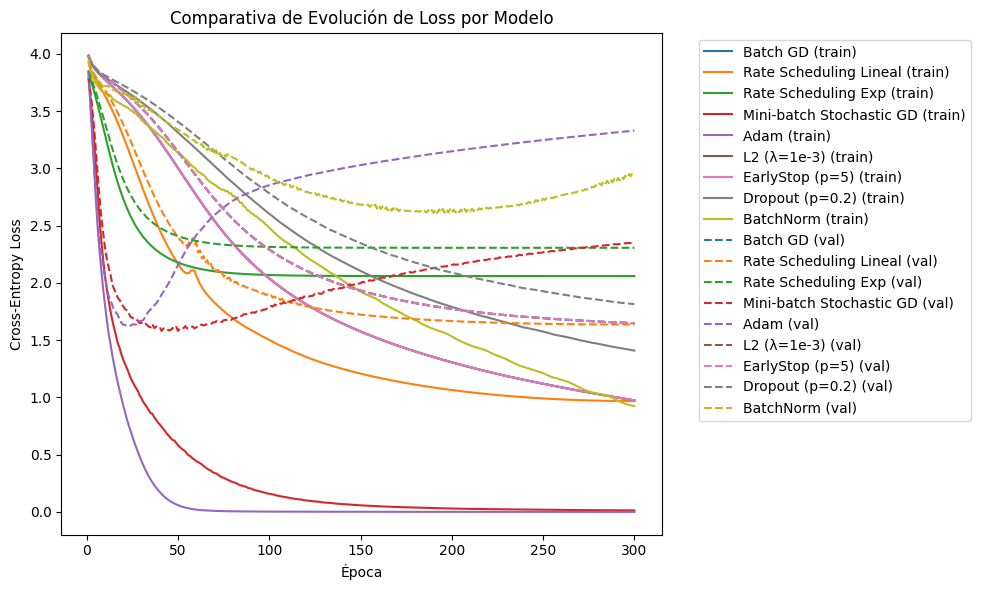

In [29]:
# --- Gráfico conjunto de las losses ---
plt.figure(figsize=(10,6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

for i, (name, losses) in enumerate(all_train_losses.items()):
    plt.plot(range(1, len(losses)+1), losses, label=f"{name} (train)", color=colors[i])

for i, (name, losses) in enumerate(all_val_losses.items()):
    plt.plot(range(1, len(losses)+1), losses, '--', label=f"{name} (val)", color=colors[i])

plt.xlabel("Época")
plt.ylabel("Cross-Entropy Loss")
plt.title("Comparativa de Evolución de Loss por Modelo")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

3.2) prueba greedy

In [ ]:
import itertools
epochs = 300

architectures = [
    # Redes ligeras (rápidas de entrenar, menos parámetros)
    [input_size, 32, n_classes],
    [input_size, 64, n_classes],
    [input_size, 64, 32, n_classes],
    
    # Redes de complejidad media (equilibrio)
    [input_size, 100, n_classes],
    [input_size, 128, 64, n_classes],
    [input_size, 100, 50, n_classes],
    [input_size, 64, 64, 32, n_classes],
    
    # Redes más profundas (más capacidad, más lentas)
    [input_size, 150, 80, n_classes],
    [input_size, 128, 64, 32, n_classes],
    [input_size, 256, 128, 64, n_classes],

    # Arquitecturas alternativas con tres capas ocultas
    [input_size, 100, 50, 25, n_classes],
    [input_size, 128, 128, 64, 32, n_classes],
    
    
]

# Hiperparámetros base
hyperparams = {
    'optimizer':      ['gd', 'mb', 'adam'],
    'batch_size':     [None, 1, 16, 32, 64, 128, 256],   # None → full‐batch si optimizer!='mb', 
                                                # 1 → puro SGD, >1 → mini‐batch
    'learning_rate':  [0.001, 0.01, 0.05, 0.1, 0.2],
    'l2_lambda':      [0.0, 1e-3, 1e-2, 1e-1],
    'dropout_p':      [0.0, 0.15, 0.2, 0.25],
    'use_batchnorm':  [False, True],
    'early_stopping': [False, True],
    'patience':       [5, 10, 20, 50],
    'lr_schedule':    ['none', 'linear', 'exp'],
}



# Define the order in which to optimize parameters (including architectures)
param_order = [
    'arch',
    'optimizer',
    'arch',
    'early_stopping',
    'patience',
    'learning_rate',
    'batch_size',
    'l2_lambda',
    'dropout_p',
    'use_batchnorm',
    'lr_schedule',
    'arch',
]

def greedy_search(architectures, hyperparams, X_train, Y_train_oh, X_val, Y_val_oh, y_train, y_val, epochs=200, seed=SEED):
    """
    Perform greedy hyperparameter search in given order.
    At each step, fix previously chosen values and pick the best for the current parameter.
    Returns a dict with the best configuration and its validation accuracy.
    """
    # Initialize best configuration dict
    best_config = {}
    best_score = -float('inf')

    # Helper to evaluate one config
    def eval_config(config):
        # Unpack config, apply defaults
        arch = config['arch']
        opt = config['optimizer']
        lr = config['learning_rate']
        bs = config['batch_size']
        l2 = config['l2_lambda']
        dp = config['dropout_p']
        bn = config['use_batchnorm']
        es = config['early_stopping']
        pat = config['patience']
        sched = config['lr_schedule']

        # Adjust batch_size for optimizer semantics
        if opt in ['gd', 'adam'] and bs is not None:
            return -float('inf')  # invalid combo
        if opt == 'mb' and bs is None:
            bs = 1  # interpret None as pure SGD

        # Build and train network
        nn = NeuralNetwork(
            layer_sizes=arch,
            learning_rate=lr,
            seed=seed,
            optimizer=opt,
            batch_size=bs,
            l2_lambda=l2,
            dropout_p=dp,
            use_batchnorm=bn,
            early_stopping=es,
            patience=pat,
        )

        # Schedule
        lr_fn = None
        if sched == 'linear':
            lr_fn = nn.get_linear_schedule(final_lr=0.001, max_epochs=epochs)
        elif sched == 'exp':
            lr_fn = nn.get_exponential_schedule(decay_rate=0.05)

        # Train
        nn.train_bp(
            X_train, Y_train_oh,
            X_val=X_val, Y_val=Y_val_oh,
            epochs=epochs,
            plot=False,
            lr_schedule=lr_fn,
        )

        # Evaluate on validation
        Yhat_v = nn.forward(X_val, train=False)
        ypred_v = cp.argmax(Yhat_v, axis=0)
        yproba_v = Yhat_v.T
        m_v = Metrics(y_true=y_val, y_pred=ypred_v, y_proba=yproba_v)
        return m_v.accuracy()

    # Iterate over parameters greedily
    for param in param_order:
        best_val = None
        param_best_score = -float('inf')

        # Get candidate values
        if param == 'arch':
            candidates = architectures
        else:
            candidates = hyperparams[param]

        for val in candidates:
            # Skip patience if early_stopping is False and param is patience
            if param == 'patience' and not best_config.get('early_stopping', False):
                break

            # Build test config
            test_config = best_config.copy()
            test_config[param] = val

            # Fill missing for eval
            for p in ['arch', 'optimizer', 'learning_rate', 'batch_size',
                      'l2_lambda', 'dropout_p', 'use_batchnorm',
                      'early_stopping', 'patience', 'lr_schedule']:
                if p not in test_config:
                    # use a default first element
                    if p == 'arch':
                        test_config[p] = architectures[0]
                    else:
                        test_config[p] = hyperparams[p][0]

            score = eval_config(test_config)

            if score > param_best_score:
                param_best_score = score
                best_val = val

        # Fix the best value
        best_config[param] = best_val
        print(f"Best {param}: {best_val} (val_acc={param_best_score:.4f})")

        # Update global best if final param
        if param == param_order[-1]:
            best_score = param_best_score

    return best_config, best_score

# Usage example:
best_cfg, best_acc = greedy_search(architectures, hyperparams,
                                   X_train, Y_train_oh,
                                   X_val, Y_val_oh,
                                   y_train, y_val,
                                   epochs=200, seed=SEED)
print("Best config:", best_cfg)
print("Validation accuracy:", best_acc)


Epochs: 100%|██████████| 200/200 [00:11<00:00, 17.99it/s]


Best arch: [784, 64, 49] (val_acc=0.0450)


Epochs: 100%|██████████| 200/200 [00:07<00:00, 26.36it/s]


Best optimizer: adam (val_acc=0.5887)


Epochs: 100%|██████████| 200/200 [00:11<00:00, 17.33it/s]


...

Best use_batchnorm: False (val_acc=0.6500)


Epochs: 100%|██████████| 200/200 [00:12<00:00, 15.45it/s]


Best lr_schedule: none (val_acc=0.6500)


Epochs:  90%|████████▉ | 179/200 [00:10<00:01, 16.28it/s]


Best arch: [784, 150, 80, 49] (val_acc=0.6500)
Best config: {'arch': [784, 150, 80, 49], 'optimizer': 'adam', 'early_stopping': True, 'patience': 10, 'learning_rate': 0.001, 'batch_size': None, 'l2_lambda': 0.1, 'dropout_p': 0.2, 'use_batchnorm': False, 'lr_schedule': 'none'}
Validation accuracy: 0.65


In [ ]:
# from tqdm import tqdm
# import itertools

epochs = 400

architectures = [
    # Redes ligeras (rápidas de entrenar, menos parámetros)
    [input_size, 32, n_classes],
    [input_size, 64, n_classes],
    [input_size, 64, 32, n_classes],
    
    # Redes de complejidad media (equilibrio)
    [input_size, 100, n_classes],
    [input_size, 128, 64, n_classes],
    [input_size, 100, 50, n_classes],
    [input_size, 100, 80, n_classes],
    [input_size, 64, 64, 32, n_classes],
    
    # Redes más profundas (más capacidad, más lentas)
    [input_size, 150, 80, n_classes],
    [input_size, 128, 64, 32, n_classes],
    [input_size, 256, 128, 64, n_classes],

    # Arquitecturas alternativas con tres capas ocultas
    [input_size, 100, 50, 25, n_classes],
    [input_size, 128, 128, 64, 32, n_classes],
    
    # extra
    # Redes de profundidad media con embudo
    [input_size, 200, 100, 50, n_classes],
    [input_size, 256, 128, 64, 32, n_classes],

    # Redes uniformes de varias capas
    [input_size, 64, 64, 64, 64, n_classes],
    [input_size, 128, 128, 128, n_classes],

    # Bottleneck pronunciado
    [input_size, 128, 32, n_classes],
    [input_size, 64, 16, n_classes],

    # Muy profundas (hasta 6 capas ocultas)
    [input_size, 256, 128, 64, 32, 16, n_classes],
    [input_size, 128, 128, 64, 64, 32, n_classes],

    # Arquitecturas “inversas” (crece luego decrece)
    [input_size, 64, 128, 64, n_classes],
    [input_size, 32, 64, 128, 64, 32, n_classes],
]

# Hiperparámetros base
hyperparams = {
    'optimizer':      ['gd', 'mb', 'adam'],
    'batch_size':     [None, 1, 16, 32, 64, 128, 256],   # None → full‐batch si optimizer!='mb', 
    'learning_rate':  [0.001, 0.005, 0.01, 0.05, 0.1, 0.15, 0.2],
    'l2_lambda':      [0.0, 1e-3, 1e-2, 1e-1],
    'dropout_p':      [0.0, 0.15, 0.2, 0.25, 0.3],
    'use_batchnorm':  [False, True],
    'early_stopping': [False, True],
    'patience':       [5, 10, 15, 20, 30, 50],
    'lr_schedule':    ['none', 'linear', 'exp'],
}

# Define the order in which to optimize parameters (including architectures)
param_order = [
    'arch',
    'optimizer',
    'arch',
    'early_stopping',
    'patience',
    'arch',
    'learning_rate',
    'batch_size',
    'l2_lambda',
    'dropout_p',
    'use_batchnorm',
    'lr_schedule',
    'learning_rate',
    'arch',
]

def greedy_search(architectures, hyperparams, X_train, Y_train_oh, X_val, Y_val_oh, y_train, y_val, epochs=200, seed=SEED):
    """
    Perform greedy hyperparameter search in given order.
    At each step, fix previously chosen values and pick the best for the current parameter.
    Returns a dict with the best configuration and its validation accuracy.
    """
    # Initialize best configuration dict
    best_config = {}
    best_score = -float('inf')

    # Helper to evaluate one config
    def eval_config(config):
        # Unpack config, apply defaults
        arch = config['arch']
        opt = config['optimizer']
        lr = config['learning_rate']
        bs = config['batch_size']
        l2 = config['l2_lambda']
        dp = config['dropout_p']
        bn = config['use_batchnorm']
        es = config['early_stopping']
        pat = config['patience']
        sched = config['lr_schedule']

        # Adjust batch_size for optimizer semantics
        if opt in ['gd', 'adam'] and bs is not None:
            return -float('inf')  # invalid combo
        if opt == 'mb' and bs is None:
            bs = 1  # interpret None as pure SGD

        # Build and train network
        nn = NeuralNetwork(
            layer_sizes=arch,
            learning_rate=lr,
            seed=seed,
            optimizer=opt,
            batch_size=bs,
            l2_lambda=l2,
            dropout_p=dp,
            use_batchnorm=bn,
            early_stopping=es,
            patience=pat,
        )

        # Schedule
        lr_fn = None
        if sched == 'linear':
            lr_fn = nn.get_linear_schedule(final_lr=0.001, max_epochs=epochs)
        elif sched == 'exp':
            lr_fn = nn.get_exponential_schedule(decay_rate=0.05)

        # Train
        nn.train_bp(
            X_train, Y_train_oh,
            X_val=X_val, Y_val=Y_val_oh,
            epochs=epochs,
            plot=False,
            lr_schedule=lr_fn,
        )

        # Evaluate on validation
        Yhat_v = nn.forward(X_val, train=False)
        ypred_v = cp.argmax(Yhat_v, axis=0)
        yproba_v = Yhat_v.T
        m_v = Metrics(y_true=y_val, y_pred=ypred_v, y_proba=yproba_v)
        return m_v.accuracy()

    # Iterate over parameters greedily
    for param in param_order:
        best_val = None
        param_best_score = -float('inf')

        # Get candidate values
        if param == 'arch':
            candidates = architectures
        else:
            candidates = hyperparams[param]

        for val in candidates:
            # Skip patience if early_stopping is False and param is patience
            if param == 'patience' and not best_config.get('early_stopping', False):
                break

            # Build test config
            test_config = best_config.copy()
            test_config[param] = val

            # Fill missing for eval
            for p in ['arch', 'optimizer', 'learning_rate', 'batch_size',
                      'l2_lambda', 'dropout_p', 'use_batchnorm',
                      'early_stopping', 'patience', 'lr_schedule']:
                if p not in test_config:
                    # use a default first element
                    if p == 'arch':
                        test_config[p] = architectures[0]
                    else:
                        test_config[p] = hyperparams[p][0]

            score = eval_config(test_config)

            if score > param_best_score:
                param_best_score = score
                best_val = val

        # Fix the best value
        best_config[param] = best_val
        print(f"Best {param}: {best_val} (val_acc={param_best_score:.4f})")

        # Update global best if final param
        if param == param_order[-1]:
            best_score = param_best_score

    return best_config, best_score

# Usage example:
best_cfg, best_acc = greedy_search(architectures, hyperparams,
                                   X_train, Y_train_oh,
                                   X_val, Y_val_oh,
                                   y_train, y_val,
                                   epochs=200, seed=SEED)
print("Best config:", best_cfg)
print("Validation accuracy:", best_acc)



Epochs: 100%|██████████| 200/200 [00:03<00:00, 51.92it/s]


Best arch: [784, 64, 49] (val_acc=0.0450)


Epochs: 100%|██████████| 200/200 [00:03<00:00, 50.46it/s]


Best optimizer: adam (val_acc=0.5887)


Epochs: 100%|██████████| 200/200 [00:04<00:00, 48.88it/s]


Best arch: [784, 128, 128, 128, 49] (val_acc=0.6438)
Best patience: None (val_acc=-inf)


Epochs:  30%|███       | 60/200 [00:02<00:05, 26.29it/s]


TypeError: '>=' not supported between instances of 'int' and 'NoneType'

In [25]:

epochs = 400

architectures = [
    # Redes ligeras (rápidas de entrenar, menos parámetros)
    [input_size, 32, n_classes],
    [input_size, 64, n_classes],
    [input_size, 64, 32, n_classes],
    
    # Redes de complejidad media (equilibrio)
    [input_size, 100, n_classes],
    [input_size, 128, 64, n_classes],
    [input_size, 100, 50, n_classes],
    [input_size, 100, 80, n_classes],
    [input_size, 64, 64, 32, n_classes],
    
    # Redes más profundas (más capacidad, más lentas)
    [input_size, 150, 80, n_classes],
    [input_size, 128, 64, 32, n_classes],
    [input_size, 256, 128, 64, n_classes],

    # Arquitecturas alternativas con tres capas ocultas
    [input_size, 100, 50, 25, n_classes],
    [input_size, 128, 128, 64, 32, n_classes],
    
    # extra
    # Redes de profundidad media con embudo
    [input_size, 200, 100, 50, n_classes],
    [input_size, 256, 128, 64, 32, n_classes],

    # Redes uniformes de varias capas
    [input_size, 64, 64, 64, 64, n_classes],
    [input_size, 128, 128, 128, n_classes],

    # Bottleneck pronunciado
    [input_size, 128, 32, n_classes],
    [input_size, 64, 16, n_classes],

    # Muy profundas (hasta 6 capas ocultas)
    [input_size, 256, 128, 64, 32, 16, n_classes],
    [input_size, 128, 128, 64, 64, 32, n_classes],

    # Arquitecturas “inversas” (crece luego decrece)
    [input_size, 64, 128, 64, n_classes],
    [input_size, 32, 64, 128, 64, 32, n_classes],
]

# Hiperparámetros base
hyperparams = {
    'optimizer':      ['gd', 'mb', 'adam'],
    'batch_size':     [None, 1, 16, 32, 64, 128, 256],   # None → full‐batch si optimizer!='mb', 
    'learning_rate':  [0.001, 0.005, 0.01, 0.05, 0.1, 0.15, 0.2],
    'l2_lambda':      [0.0, 1e-3, 1e-2, 1e-1],
    'dropout_p':      [0.0, 0.15, 0.2, 0.25, 0.3],
    'use_batchnorm':  [False, True],
    'early_stopping': [False, True],
    'patience':       [5, 10, 15, 20, 30, 50],
    'lr_schedule':    ['none', 'linear', 'exp'],
}

# Define the order in which to optimize parameters (including architectures)
param_order = [
    'arch',
    'optimizer',
    'arch',
    'early_stopping',
    'patience',
    'arch',
    'learning_rate',
    'batch_size',
    'dropout_p',
    'l2_lambda',
    'use_batchnorm',
    'lr_schedule',
    'learning_rate',
    'arch',
]


def get_schedule(nn, name, epochs):
    if name == 'linear':
        return nn.get_linear_schedule(final_lr=0.001, max_epochs=epochs)
    if name == 'exp':
        return nn.get_exponential_schedule(decay_rate=0.05)
    return None

def greedy_search(architectures, hyperparams,
                  X_train, Y_train_oh, X_val, Y_val_oh,
                  y_train, y_val,
                  epochs=200, seed=SEED):

    best_config = {}
    best_score = -float('inf')

    def eval_config(cfg):
        # Desempaquetar y aplicar defaults
        arch = cfg['arch']
        opt  = cfg['optimizer']
        lr   = cfg['learning_rate']
        bs   = cfg['batch_size']
        l2   = cfg['l2_lambda']
        dp   = cfg['dropout_p']
        bn   = cfg['use_batchnorm']
        es   = cfg['early_stopping']
        pat  = cfg['patience']
        sched= cfg['lr_schedule']

        # Reglas de batch_size
        if opt in ['gd', 'adam'] and bs is not None:
            return -float('inf')
        if opt == 'mb' and bs is None:
            bs = 1

        nn = NeuralNetwork(
            layer_sizes=arch,
            learning_rate=lr,
            seed=seed,
            optimizer=opt,
            batch_size=bs,
            l2_lambda=l2,
            dropout_p=dp,
            use_batchnorm=bn,
            early_stopping=es,
            patience=pat,
        )

        lr_fn = get_schedule(nn, sched, epochs)
        nn.train_bp(
            X_train, Y_train_oh,
            X_val=X_val, Y_val=Y_val_oh,
            epochs=epochs,
            plot=False,
            lr_schedule=lr_fn,
        )

        Yhat_v = nn.forward(X_val, train=False)
        ypred_v = cp.argmax(Yhat_v, axis=0)
        yproba_v = Yhat_v.T
        m_v = Metrics(y_true=y_val, y_pred=ypred_v, y_proba=yproba_v)
        return m_v.accuracy()

    for param in param_order:
        # 1) Tratamiento especial de early_stopping + patience
        if param == 'early_stopping':
            best_es      = False
            best_pat     = hyperparams['patience'][0]
            best_es_score= -float('inf')

            # Caso sin early stopping
            cfg0 = {**best_config, 'early_stopping': False, 'patience': hyperparams['patience'][0]}
            # llenar defaults
            for p in ['arch','optimizer','learning_rate','batch_size',
                      'l2_lambda','dropout_p','use_batchnorm',
                      'lr_schedule']:
                if p not in cfg0:
                    cfg0[p] = architectures[0] if p=='arch' else hyperparams[p][0]
            score0 = eval_config(cfg0)
            if score0 > best_es_score:
                best_es_score, best_es, best_pat = score0, False, hyperparams['patience'][0]

            # Caso con early stopping: probar todas las patiences
            for pat in hyperparams['patience']:
                cfg1 = {**best_config, 'early_stopping': True, 'patience': pat}
                for p in ['arch','optimizer','learning_rate','batch_size',
                          'l2_lambda','dropout_p','use_batchnorm',
                          'lr_schedule']:
                    if p not in cfg1:
                        cfg1[p] = architectures[0] if p=='arch' else hyperparams[p][0]
                sc = eval_config(cfg1)
                if sc > best_es_score:
                    best_es_score, best_es, best_pat = sc, True, pat

            # Fijar la mejor pareja (early_stopping, patience)
            best_config['early_stopping'] = best_es
            best_config['patience']      = best_pat
            print(f"Best early_stopping: {best_es}  (patience={best_pat}) -> val_acc={best_es_score:.4f}")
            # actualizar best_score si es último
            if param == param_order[-1]:
                best_score = best_es_score

            continue

        # 2) Saltar la entrada separada de 'patience'
        if param == 'patience':
            continue

        # 3) Lógica normal para los demás parámetros
        candidates = architectures if param=='arch' else hyperparams[param]
        param_best_score = -float('inf')
        best_val = None

        for val in candidates:
            cfg = {**best_config, param: val}
            # llenar defaults
            for p in ['arch','optimizer','learning_rate','batch_size',
                      'l2_lambda','dropout_p','use_batchnorm',
                      'early_stopping','patience','lr_schedule']:
                if p not in cfg:
                    cfg[p] = architectures[0] if p=='arch' else hyperparams[p][0]

            sc = eval_config(cfg)
            if sc > param_best_score:
                param_best_score, best_val = sc, val

        best_config[param] = best_val
        print(f"Best {param}: {best_val} -> val_acc={param_best_score:.4f}")
        if param == param_order[-1]:
            best_score = param_best_score

    return best_config, best_score

# Ejemplo de uso:
best_cfg, best_acc = greedy_search(
    architectures, hyperparams,
    X_train, Y_train_oh,
    X_val, Y_val_oh,
    y_train, y_val,
    epochs=epochs, seed=SEED
)
print("Configuración óptima:", best_cfg)
print("Accuracy en validación:", best_acc)


Epochs: 100%|██████████| 400/400 [00:07<00:00, 51.99it/s]


Best arch: [784, 200, 100, 50, 49] -> val_acc=0.0475


Epochs: 100%|██████████| 400/400 [00:24<00:00, 16.40it/s]


Best optimizer: mb -> val_acc=0.6350


Epochs:  15%|█▍        | 59/400 [18:12<1:45:13, 18.51s/it]


KeyboardInterrupt: 

### `4.` **Desarrollo de una Red Neuronal con PyTorch**


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim

#### **M2** - entrenando una red neuronal con la arquitectura y los hiperparámetros hallados

In [ ]:
# ----------------------------
# Datos y parámetros globales
# ----------------------------
input_size = X_train.shape[1]
n_classes  = int(cp.max(y_train)) + 1

batch_size  = 128
lr          = 0.01
l2_lambda   = 1e-3
dropout_p   = 0.2
use_bn      = False
early_stop  = True
patience    = 20
lr_sched    = 'none'    # 'none'|'linear'|'exp'

# {'arch': [784, 128, 128, 128, 49], 'optimizer': 'adam', 'early_stopping': False, 'patience': None, 'learning_rate': 0.01, 'batch_size': None, 'l2_lambda': 0.1, 'dropout_p': 0.0, 'use_batchnorm': False, 'lr_schedule': 'none'}

epochs_M2   = 400
epochs_M3   = 200       # menor para exploración

# ----------------------------
# Auxiliares
# ----------------------------
def get_dataloader(X, y, batch_size):
    X_t = torch.tensor(cp.asnumpy(X), dtype=torch.float32)
    y_t = torch.tensor(cp.asnumpy(y), dtype=torch.long)
    ds  = torch.utils.data.TensorDataset(X_t, y_t)
    return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)

def build_scheduler(optimizer, lr_sched, patience, n_batches):
    if lr_sched == 'linear':
        return optim.lr_scheduler.LinearLR(
            optimizer, start_factor=1.0, end_factor=0.0,
            total_iters=patience * n_batches
        )
    if lr_sched == 'exp':
        return optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)
    return None

def train_model(ModelClass, conf, epochs):
    train_dl = get_dataloader(X_train, y_train, conf['batch_size'])
    val_dl   = get_dataloader(X_val,   y_val,   conf['batch_size'])

    model     = ModelClass(conf)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),
                           lr=conf['learning_rate'],
                           weight_decay=conf['l2_lambda'])
    scheduler = build_scheduler(optimizer, conf['lr_schedule'],
                                conf['patience'], len(train_dl))

    best_val_loss = float('inf')
    patience_ctr  = 0
    best_state    = None

    for epoch in range(1, epochs + 1):
        model.train()
        for Xb, yb in train_dl:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            if scheduler:
                scheduler.step()

        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for Xb, yb in val_dl:
                logits = model(Xb)
                l = criterion(logits, yb)
                val_loss += l.item() * Xb.size(0)
                preds = logits.argmax(dim=1)
                all_preds.append(cp.array(preds.cpu().numpy()))
                all_labels.append(cp.array(yb.cpu().numpy()))

        val_loss /= len(val_dl.dataset)
        y_true = cp.concatenate(all_labels)
        y_pred = cp.concatenate(all_preds)
        m = Metrics(y_true, y_pred)
        acc = m.accuracy()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_ctr  = 0
            best_state    = model.state_dict()
        else:
            patience_ctr += 1
            if conf['early_stopping'] and patience_ctr >= conf['patience']:
                break

    model.load_state_dict(best_state)
    return model


In [ ]:

# ----------------------------
# 1) Entrena y evalúa M2
# ----------------------------
class MLP_M2(nn.Module):
    def __init__(self, conf):
        super().__init__()
        layers = []
        sizes  = conf['arch']
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i+1]))
            if i < len(sizes) - 2:
                if conf['use_batchnorm']:
                    layers.append(nn.BatchNorm1d(sizes[i+1]))
                layers.append(nn.ReLU())
                if conf['dropout_p'] > 0:
                    layers.append(nn.Dropout(conf['dropout_p']))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

conf_M2 = {
    'arch':          [input_size, 128, 64, 32, n_classes],
    'optimizer':     'adam',
    'batch_size':    batch_size,
    'learning_rate': lr,
    'l2_lambda':     l2_lambda,
    'dropout_p':     dropout_p,
    'use_batchnorm': use_bn,
    'early_stopping': early_stop,
    'patience':       patience,
    'lr_schedule':    lr_sched,
}

print(">>> Entrenando M2...")
M2 = train_model(MLP_M2, conf_M2, epochs_M2)

# Evaluación final de M2
with torch.no_grad():
    Xv_t = torch.tensor(cp.asnumpy(X_val), dtype=torch.float32)
    logits = M2(Xv_t)
    probs  = torch.softmax(logits, dim=1)
    preds  = probs.argmax(dim=1)

y_true = y_val
y_pred = cp.array(preds.cpu().numpy())
y_proba= cp.array(probs.cpu().numpy())

print("### M2: Métricas finales")
m2_metrics = Metrics(y_true, y_pred, y_proba)
m2_metrics.report_metrics(title="Desempeño M2")


>>> Entrenando M2...


IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 1)

#### **M3** - explorando cambios en la cantidad de capas ocultas y unidades ocultas por capa

In [ ]:

# ----------------------------
# 2) Explora arquitecturas para M3
# ----------------------------
architectures = [
    [input_size, 32,        n_classes],
    [input_size, 64,        n_classes],
    [input_size, 64, 32,    n_classes],
    [input_size, 100,       n_classes],
    [input_size, 128, 64,   n_classes],
    [input_size, 100, 50,   n_classes],
    [input_size, 64, 64, 32,n_classes],
    [input_size, 150, 80,   n_classes],
    [input_size, 128, 64,32,n_classes],
    [input_size, 256,128,64,n_classes],
    [input_size, 100,50,25, n_classes],
    [input_size,128,128,64,32,n_classes],
    [input_size,256,       n_classes],
    [input_size,512,       n_classes],
    [input_size,200,100,50,           n_classes],
    [input_size,256,128,64,32,        n_classes],
    [input_size,64,64,64,64,           n_classes],
    [input_size,128,128,128,           n_classes],
    [input_size,128,32,                n_classes],
    [input_size,64,16,                 n_classes],
    [input_size,256,128,64,32,16,      n_classes],
    [input_size,128,128,64,64,32,      n_classes],
    [input_size,64,128,64,              n_classes],
    [input_size,32,64,128,64,32,        n_classes],
]

class MLP_M3(nn.Module):
    def __init__(self, conf):
        super().__init__()
        layers = []
        sizes  = conf['arch']
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i+1]))
            if i < len(sizes) - 2:
                if conf['use_batchnorm']:
                    layers.append(nn.BatchNorm1d(sizes[i+1]))
                layers.append(nn.ReLU())
                if conf['dropout_p'] > 0:
                    layers.append(nn.Dropout(conf['dropout_p']))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

best_acc = -1.0
best_arch = None
best_model= None

print("\n>>> Explorando arquitecturas para M3...")
for arch in architectures:
    conf = conf_M2.copy()
    conf['arch'] = arch
    model = train_model(MLP_M3, conf, epochs_M3)

    # Evalúa una sola pasada para medir accuracy
    with torch.no_grad():
        Xv_t = torch.tensor(cp.asnumpy(X_val), dtype=torch.float32)
        logits = model(Xv_t)
        preds  = logits.argmax(dim=1)
    acc = float((preds.cpu().numpy() == cp.asnumpy(y_val)).mean())

    print(f"  {arch} -> Acc={acc:.4f}")
    if acc > best_acc:
        best_acc  = acc
        best_arch = arch
        best_model= model

print(f"\n>> Mejor M3: {best_arch} con Acc={best_acc:.4f}")

# Evaluación final de M3
with torch.no_grad():
    Xv_t = torch.tensor(cp.asnumpy(X_val), dtype=torch.float32)
    logits = best_model(Xv_t)
    probs  = torch.softmax(logits, dim=1)
    preds  = probs.argmax(dim=1)

y_pred_m3 = cp.array(preds.cpu().numpy())
y_proba_m3= cp.array(probs.cpu().numpy())
y_true    = y_val

print("### M3: Métricas finales")
m3_metrics = Metrics(y_true, y_pred_m3, y_proba_m3)
m3_metrics.report_metrics(title="Desempeño M3")


#### **M4** - buscando una estructura que produzca overfitting

#### 4.3) Comparación entre **M0**, **M1**, **M2**, **M3** y **M4**

In [ ]:
import torch
import cupy as cp
import pandas as pd

# 1) Carga y normalización idéntica al entrenamiento
X_comp = cp.load('data/X_COMP.npy')     # shape (n_samples, n_features)
X_comp = X_comp / 255.0            # **normalización**

# 2) PyTorch tensor
X_comp_t = torch.tensor(cp.asnumpy(X_comp), dtype=torch.float32)

# 3) Modelo M3 ya entrenado (asegúrate de haber recargado best_model)
best_model.eval()

# 4) Inferencia
with torch.no_grad():
    logits = best_model(X_comp_t)
    probs  = torch.softmax(logits, dim=1)

# 5) A CuPy → pandas
probs_cp = cp.array(probs.cpu().numpy())
col_names = [f"Clase_{i}" for i in range(probs_cp.shape[1])]
df = pd.DataFrame(probs_cp.get(), columns=col_names)

# 6) Guardado
df.to_csv('Tissera_AnaPaula_predicciones.csv', index=False)
print("Generado Tissera_AnaPaula_predicciones.csv con normalización.")
